## **computer vision - lab 2 - task 1**
### **diagnostic enhancement of chest x-rays**
#### **23K-0074**

#### **setup** - imports and helper functions (log, gamma, colour balance, plotting)

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("output", exist_ok=True)


def load_gray(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"could not read '{path}' - put the sample file in the data/ folder (see README.md)")
    return img


def log_transform(img):
    # s = c * log(1 + r), with c chosen so the brightest input maps to 255
    f = img.astype(np.float64)
    c = 255.0 / np.log1p(max(f.max(), 1.0))
    return np.clip(c * np.log1p(f), 0, 255).astype(np.uint8)


def gamma_transform(img, gamma):
    # s = 255 * (r / 255) ^ gamma  (gamma < 1 brightens, gamma > 1 darkens)
    f = img.astype(np.float64) / 255.0
    return np.clip(255.0 * np.power(f, gamma), 0, 255).astype(np.uint8)


def gray_world_balance(bgr):
    # scale each channel so its mean equals the overall mean -> removes a global colour cast
    f = bgr.astype(np.float64)
    means = f.reshape(-1, 3).mean(axis=0)
    gain = means.mean() / np.maximum(means, 1e-6)
    return np.clip(f * gain, 0, 255).astype(np.uint8)


def show(images, titles, figsize=(15, 5), save=None):
    fig, axes = plt.subplots(1, len(images), figsize=figsize)
    axes = np.atleast_1d(axes)
    for ax, im, t in zip(axes, images, titles):
        if im.ndim == 2:
            ax.imshow(im, cmap="gray", vmin=0, vmax=255)
        else:
            ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        ax.set_title(t)
        ax.axis("off")
    plt.tight_layout()
    if save:
        plt.savefig(os.path.join("output", save), dpi=120, bbox_inches="tight")
    plt.show()

#### **1. load and display**
load the raw chest x-ray (a pneumonia case from the dataset) as a single-channel grayscale matrix.

shape: (232, 232), dtype: uint8, min: 0, max: 255, mean: 98.6


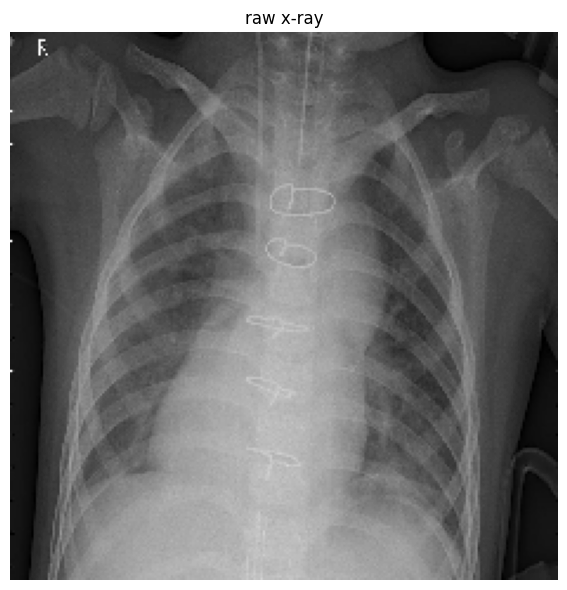

In [2]:
raw = load_gray("data/xray_1.png")
print(f"shape: {raw.shape}, dtype: {raw.dtype}, min: {raw.min()}, max: {raw.max()}, mean: {raw.mean():.1f}")
show([raw], ["raw x-ray"], figsize=(6, 6), save="01_raw.png")

#### **2. contrast enhancement - histogram equalization**
`cv2.equalizeHist` uses the cumulative histogram as a mapping, so the pixel intensities get spread over the full 0-255 range.

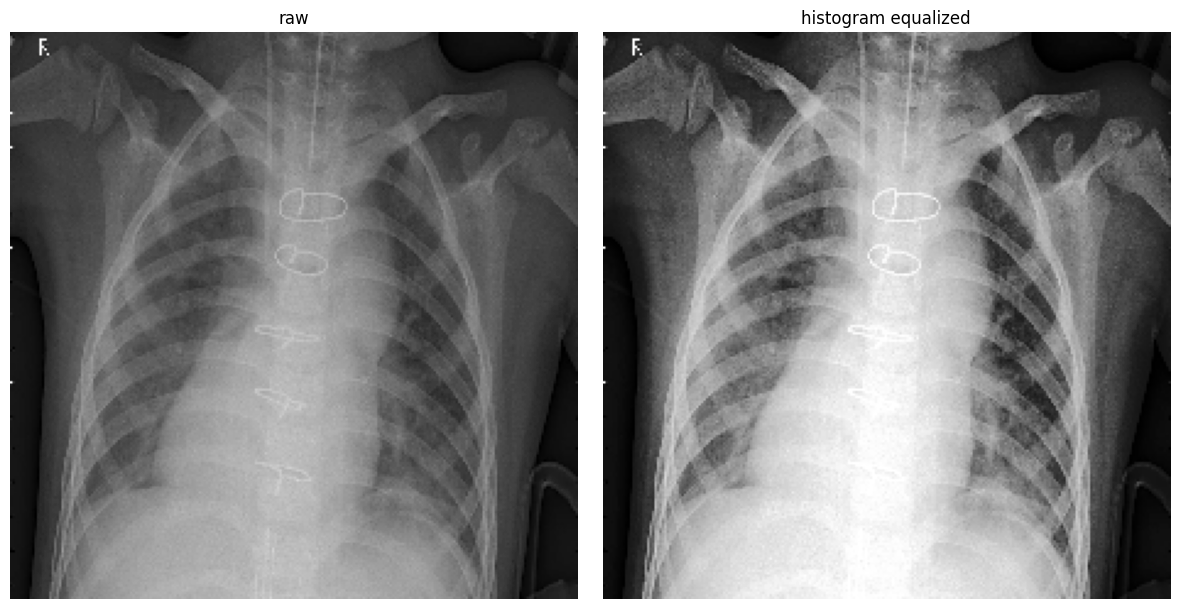

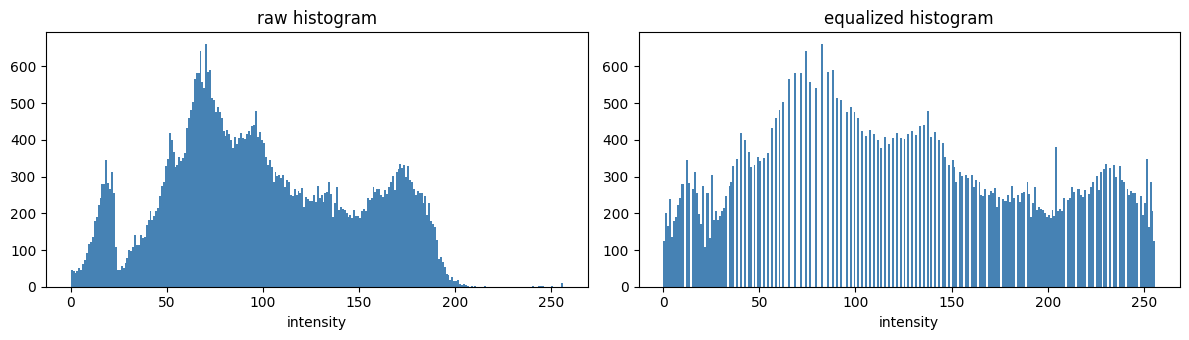

std dev (contrast)  raw: 48.3  equalized: 73.6


In [3]:
eq = cv2.equalizeHist(raw)
cv2.imwrite("output/02_equalized.png", eq)

show([raw, eq], ["raw", "histogram equalized"], figsize=(12, 6), save="02_raw_vs_equalized.png")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for ax, im, t in zip(axes, [raw, eq], ["raw histogram", "equalized histogram"]):
    ax.hist(im.ravel(), bins=256, range=(0, 256), color="steelblue")
    ax.set_title(t)
    ax.set_xlabel("intensity")
plt.tight_layout()
plt.savefig("output/02_histograms.png", dpi=120)
plt.show()

print(f"std dev (contrast)  raw: {raw.std():.1f}  equalized: {eq.std():.1f}")

**observation:**
- **raw image:** the intensities are squeezed into the middle gray range (std dev **48.3**), so the lungs look flat and hazy.
- **after equalization:** the histogram spreads across the full 0-255 range and the std dev rises to **73.6** (about 52% more contrast).
- **newly visible structures:**
  - the dark air-filled lung spaces now stand out clearly between the ribs
  - patchy white cloudiness (pneumonia infiltrates), especially in the lower lung fields
  - the full rib outlines
  - the sternal wires and clips of a previous chest operation
- **trade-off:** the dense centre of the chest (heart and spine) is pushed close to pure white, and the background grain is more visible.

#### **3. color mapping - COLORMAP_JET**

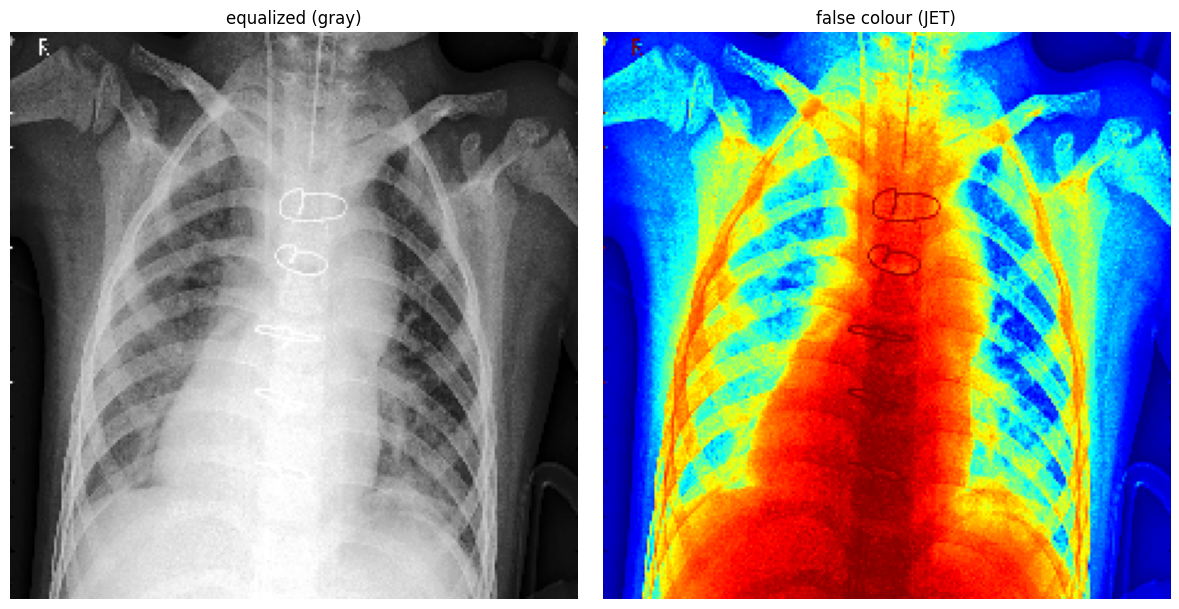

In [4]:
jet = cv2.applyColorMap(eq, cv2.COLORMAP_JET)
cv2.imwrite("output/03_jet.png", jet)
show([eq, jet], ["equalized (gray)", "false colour (JET)"], figsize=(12, 6), save="03_gray_vs_jet.png")

**observation:**
- **why colour helps:** the eye can tell apart only a few dozen shades of gray, but it is far better at telling hues apart. JET maps intensity to colour: blue for low values, then cyan, green, yellow and red for the highest.
- **in this x-ray:**
  - the air-filled lungs are **blue**
  - the ribs and soft tissue are **cyan / yellow**
  - the heart, spine and diaphragm are **red**
- **pneumonia patches:** in the lower lungs they appear as **cyan-green islands inside the blue lung**. In gray they differ from their surroundings by only a few levels, but as colours the edge of each hazy patch is immediately obvious. This is how false colour helps spot subtle fluid boundaries.

#### **4. color balance**
simulated lighting correction using the **gray-world** assumption: the average colour of a scene should be neutral gray, so each B/G/R channel is multiplied by `overall_mean / channel_mean`.

jet       channel means  B:  119.0  G:  127.7  R:  120.3
balanced  channel means  B:  120.3  G:  122.0  R:  121.0


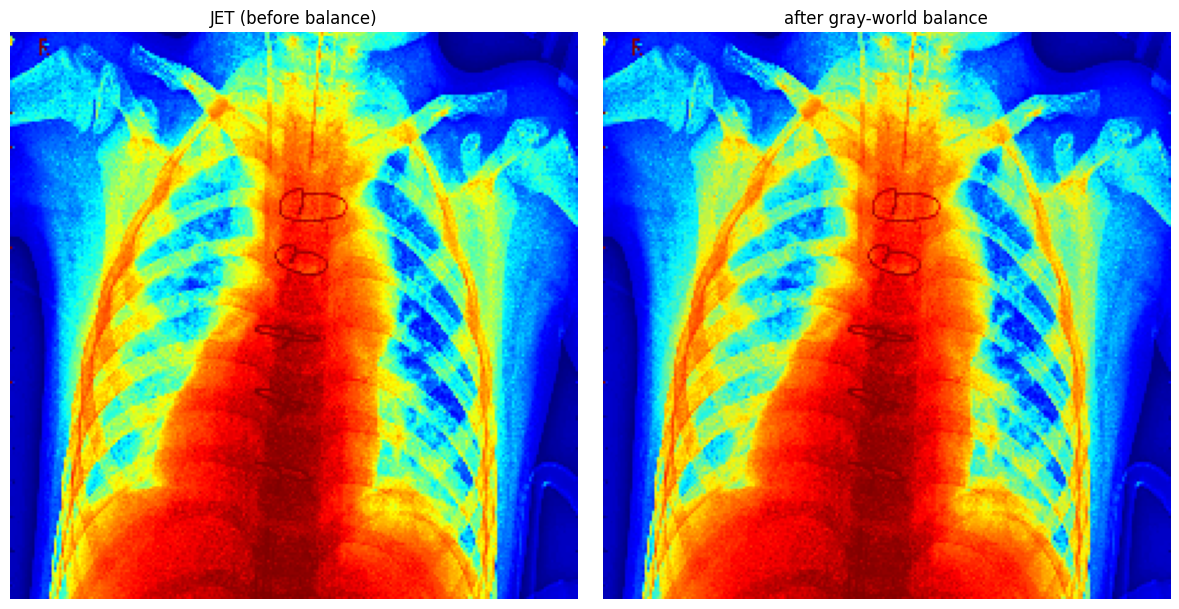

In [5]:
balanced = gray_world_balance(jet)
cv2.imwrite("output/04_balanced.png", balanced)

for name, im in [("jet", jet), ("balanced", balanced)]:
    b, g, r = im.reshape(-1, 3).mean(axis=0)
    print(f"{name:9s} channel means  B: {b:6.1f}  G: {g:6.1f}  R: {r:6.1f}")

show([jet, balanced], ["JET (before balance)", "after gray-world balance"], figsize=(12, 6), save="04_color_balance.png")

**observation:**
- **before balancing:** the JET image had a slight **green cast**. The channel means were B 119.0, G 127.7 and R 120.3, so green was about 8 levels higher than the others.
- **after gray-world balancing:** the means are B 120.3, G 122.0 and R 121.0, all within 2 levels of each other.
- **visual change:** small, because this image had only a mild cast. The correction is still useful because it makes the colours consistent from image to image: after balancing, colour differences come from real intensity changes rather than from how bright or dark the original x-ray was.

#### **5. color filtering (thresholding)**
dense tissue (bone, dense fluid) shows up as the brightest pixels. a strict binary threshold keeps only those.

pixels kept: 21.6%


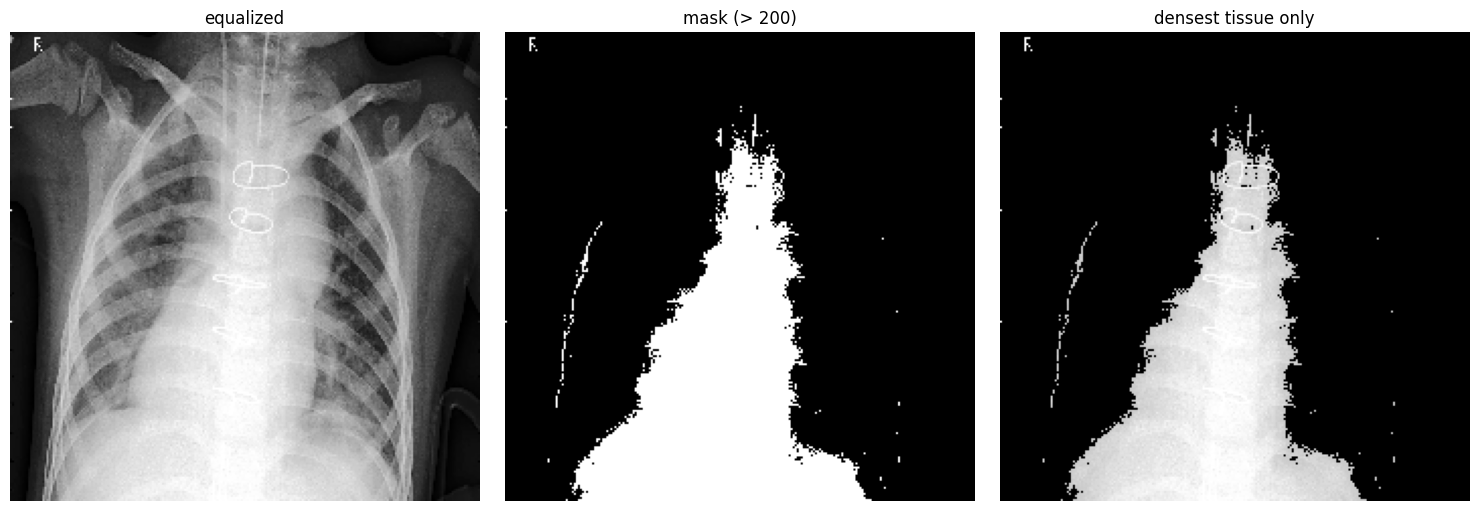

In [6]:
THRESH = 200
_, mask = cv2.threshold(eq, THRESH, 255, cv2.THRESH_BINARY)
dense_only = cv2.bitwise_and(eq, eq, mask=mask)
cv2.imwrite("output/05_mask.png", mask)
cv2.imwrite("output/05_dense_only.png", dense_only)

print(f"pixels kept: {100 * (mask > 0).mean():.1f}%")
show([eq, mask, dense_only], ["equalized", f"mask (> {THRESH})", "densest tissue only"], save="05_threshold.png")

**observation:**
- **what was kept:** **21.6%** of the pixels survive the threshold of 200. Almost all of them form one solid shape: the heart, the spine running behind it and the region above the diaphragm, which is the densest, most x-ray-blocking part of the chest. A thin rib edge, the sternal wires and the "R" marker in the corner also pass.
- **what was removed:** the lungs and outer soft tissue are masked to black.
- **limitation of a global threshold:** individual ribs mostly *don't* pass. After equalization the whole central shadow is brighter than a single rib, so one global threshold picks out the densest *region* rather than every bone. Isolating the ribs would need a threshold that adapts to each area of the image (for example `cv2.adaptiveThreshold`).

#### **6. logarithmic transformation**
applied to the **raw** underexposed image: `s = c · log(1 + r)` with `c = 255 / log(1 + max(r))`. the log curve is steep for small values, so dark pixels are stretched a lot while bright pixels are compressed.

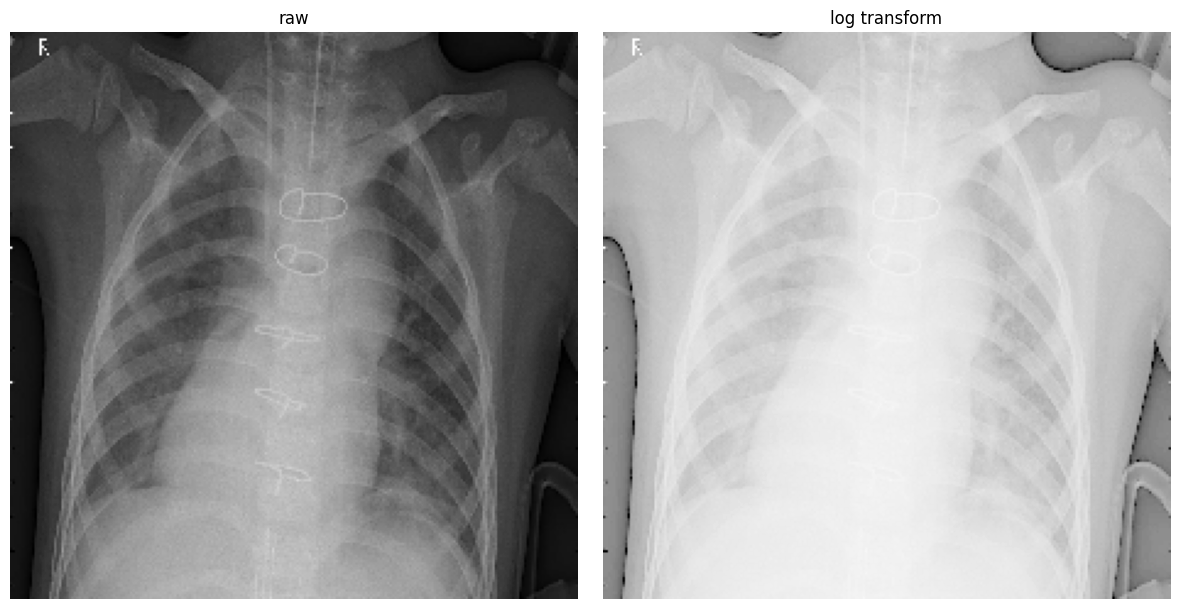

mean intensity  raw: 98.6  log: 203.5


In [7]:
log_img = log_transform(raw)
cv2.imwrite("output/06_log.png", log_img)
show([raw, log_img], ["raw", "log transform"], figsize=(12, 6), save="06_log.png")
print(f"mean intensity  raw: {raw.mean():.1f}  log: {log_img.mean():.1f}")

**observation:**
- **what log does here:** the mean brightness jumps from **98.6 to 203.5**. The dark areas (the background at the sides, the soft tissue of the armpits and shoulders, and the outer edge of the ribcage) are lifted and become easy to see.
- **the downside:** this x-ray is only mildly underexposed, so the log curve over-brightens it. The lungs wash out to light gray and lose most of the contrast that equalization gave them.
- **takeaway:** log is the right tool for a **very dark** image. For a normally exposed one it is too aggressive, which is why a gentler, tunable curve (gamma, next step) is useful.

#### **7. power-law (gamma) transformation**
`s = 255 · (r / 255)^γ` with **γ < 1**. compared with log, gamma gives a gentler, tunable curve - it lifts the midtones while reducing the harsh bone-vs-background contrast.

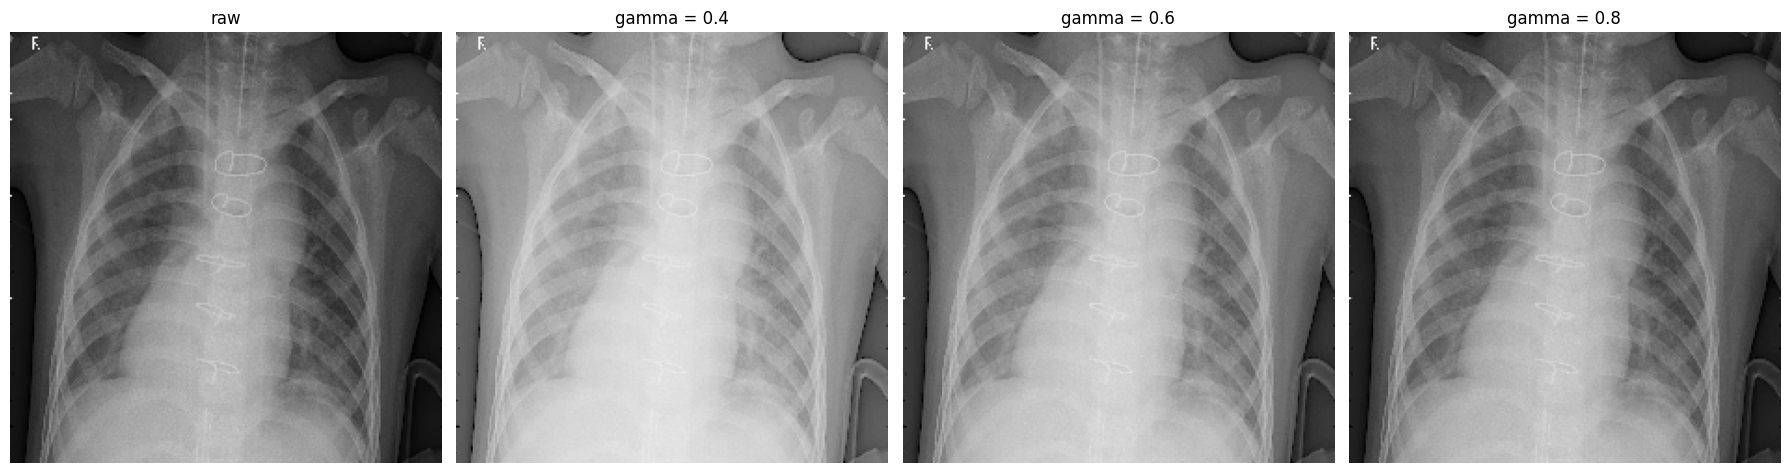

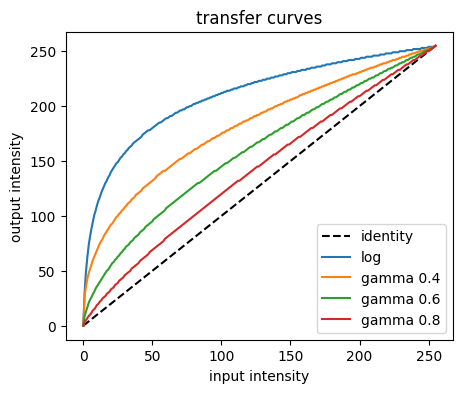

In [8]:
gammas = [0.4, 0.6, 0.8]
outs = [gamma_transform(raw, g) for g in gammas]
for g, im in zip(gammas, outs):
    cv2.imwrite(f"output/07_gamma_{g}.png", im)
show([raw] + outs, ["raw"] + [f"gamma = {g}" for g in gammas], figsize=(18, 5), save="07_gamma.png")

# plot the transfer curves
r = np.arange(256)
plt.figure(figsize=(5, 4))
plt.plot(r, r, "k--", label="identity")
plt.plot(r, log_transform(r.astype(np.uint8)), label="log")
for g in gammas:
    plt.plot(r, gamma_transform(r.astype(np.uint8), g), label=f"gamma {g}")
plt.xlabel("input intensity"); plt.ylabel("output intensity"); plt.legend(); plt.title("transfer curves")
plt.savefig("output/07_curves.png", dpi=120, bbox_inches="tight")
plt.show()

**observation:**
- **γ = 0.4:** washes the image out, similar to the log transform.
- **γ = 0.8:** stays close to the raw image.
- **γ = 0.6 (best for this image):**
  - the soft tissue and lung markings get brighter and easier to read
  - the bright bones and heart are compressed toward the top of the range, so the harsh bone-vs-background contrast is softened
  - unlike log, the lungs keep their texture
- **why (see the transfer-curve plot):** all the curves sit above the identity line, so they all brighten. Log is the steepest in the darks, and gamma lets you choose how strongly to brighten.

#### **summary**
| operation | result on this x-ray |
|---|---|
| histogram equalization | contrast (std dev) 48.3 → 73.6; lung markings, infiltrates and ribs clearly visible |
| COLORMAP_JET | lungs blue, heart/spine red; infiltrates show up as cyan-green patches |
| gray-world balance | removed a mild green cast (channel means now within 2 levels) |
| threshold (> 200) | kept 21.6%: the dense heart/spine region, not individual ribs |
| log | mean 98.6 → 203.5; reveals the outer ribcage but washes out the lungs |
| gamma (γ < 1) | γ ≈ 0.6 lifts soft tissue while keeping lung texture |

all results are saved in `output/`.